# Pivot Table

A pivot table is a powerful data summarization tool used in data analysis. It allows you to reorganize and summarize tabular data in a flexible manner, providing a compact representation of complex data relationships. Pivot tables enable you to aggregate and visualize data based on one or more key variables, making it easier to identify patterns and trends within your dataset.



# Creating a Pivot Table in Pandas

In pandas, you can create a pivot table using the pivot_table() function. Let's go through the basic syntax:

In [3]:
import pandas as pd
import numpy as np
# Create a DataFrame
data = {
    'Date': ['2022-01-01', '2022-01-01', '2022-01-02', '2022-01-02'],
    'Category': ['A', 'B', 'A', 'B'],
    'Value': [10, 20, 30, 40]
}
df = pd.DataFrame(data)

# Create a pivot table
pivot_table = df.pivot_table(values='Value', index='Date', columns='Category', aggfunc='sum')
print(pivot_table)


Category     A   B
Date              
2022-01-01  10  20
2022-01-02  30  40


In this example:

values: The column to aggregate.
index: The column to use as the row index in the pivot table.
columns: The column to use as the column index in the pivot table.
aggfunc: The aggregation function to apply when multiple values are present for the same index/column pair. It defaults to 'mean'.

In [ ]:
data = {}
np.random.seed(2)
for i in [chr(x) for x in range(65,70)]:
  data['col'+i] = np.random.randint(1,100,10)
data['orderID'] = np.random.choice(['A', 'B', 'C'], 10)
data['product'] = np.random.choice(['Product1', 'Product2', 'Product3'], 10)
data['customer'] = np.random.choice(['Customer1', 'Customer2', 'Customer3', 'Customer4'], 10)
df = pd.DataFrame(data)


In [ ]:
df

,colA,colB,colC,colD,colE,orderID,product,customer
0,41,96,68,69,51,B,Product2,Customer3
1,16,76,5,47,5,C,Product2,Customer1
2,73,86,43,71,91,B,Product2,Customer1
3,23,48,52,96,64,B,Product3,Customer3
4,44,64,39,84,80,A,Product1,Customer3
5,83,32,34,32,50,B,Product3,Customer1
6,76,91,59,67,40,C,Product3,Customer3
7,8,21,68,81,47,A,Product1,Customer1
8,35,38,70,53,9,C,Product1,Customer2
9,50,40,89,77,51,B,Product3,Customer3


In [ ]:
pivot_table2 = df.pivot_table(values='colA', index='orderID', columns='product', aggfunc=np.mean)
print(pivot_table2.to_string())


product  Product1  Product2  Product3
orderID                              
A            26.0       NaN       NaN
B             NaN      57.0      52.0
C            35.0      16.0      76.0


#Operations with Pivot Tables

Aggregation Functions
You can specify different aggregation functions when creating a pivot table. Common aggregation functions include 'sum', 'mean', 'count', 'max', and 'min'. For example:

In [ ]:
pivot_table3 = df.pivot_table(values='colA', index='orderID', columns='product', aggfunc='max')
pivot_table3

product,Product1,Product2,Product3
orderID,,,
A,44.0,NaN,NaN
B,NaN,73.0,83.0
C,35.0,16.0,76.0


In [ ]:
pivot_table = df.pivot_table(values='Value', index='Date', columns='Category', aggfunc='max')
pivot_table

Category,A,B
Date,,
2022-01-01,10,20
2022-01-02,30,40


#Multi-level Pivot Tables
#You can create pivot tables with hierarchical row and column indexes:

In [ ]:
pivot_table = df.pivot_table(values='Value', index=['Date', 'Category'], aggfunc='sum')
pivot_table

Value
Date       Category       
2022-01-01 A            10
           B            20
2022-01-02 A            30
           B            40

In [ ]:
pivot_table4 = df.pivot_table(values='colA', index=['orderID','customer'], columns='product', aggfunc='max')
pivot_table4

product            Product1  Product2  Product3
orderID customer                               
A       Customer1       8.0       NaN       NaN
        Customer3      44.0       NaN       NaN
B       Customer1       NaN      73.0      83.0
        Customer3       NaN      41.0      50.0
C       Customer1       NaN      16.0       NaN
        Customer2      35.0       NaN       NaN
        Customer3       NaN       NaN      76.0

##Handling Missing Values. You can specify how missing values are handled using the fill_value parameter:

In [ ]:
# Pivot table with fill value for missing combinations

pivot_table5 = df.pivot_table(values='colA', index='orderID', columns='product', aggfunc=np.mean, fill_value=0)
pivot_table5


product,Product1,Product2,Product3
orderID,,,
A,26,0,0
B,0,57,52
C,35,16,76


In [ ]:
pivot_table6 = df.pivot_table(values='colA', index=['orderID','customer'], columns='product', aggfunc='max', fill_value = 0)
pivot_table6

product            Product1  Product2  Product3
orderID customer                               
A       Customer1         8         0         0
        Customer3        44         0         0
B       Customer1         0        73        83
        Customer3         0        41        50
C       Customer1         0        16         0
        Customer2        35         0         0
        Customer3         0         0        76

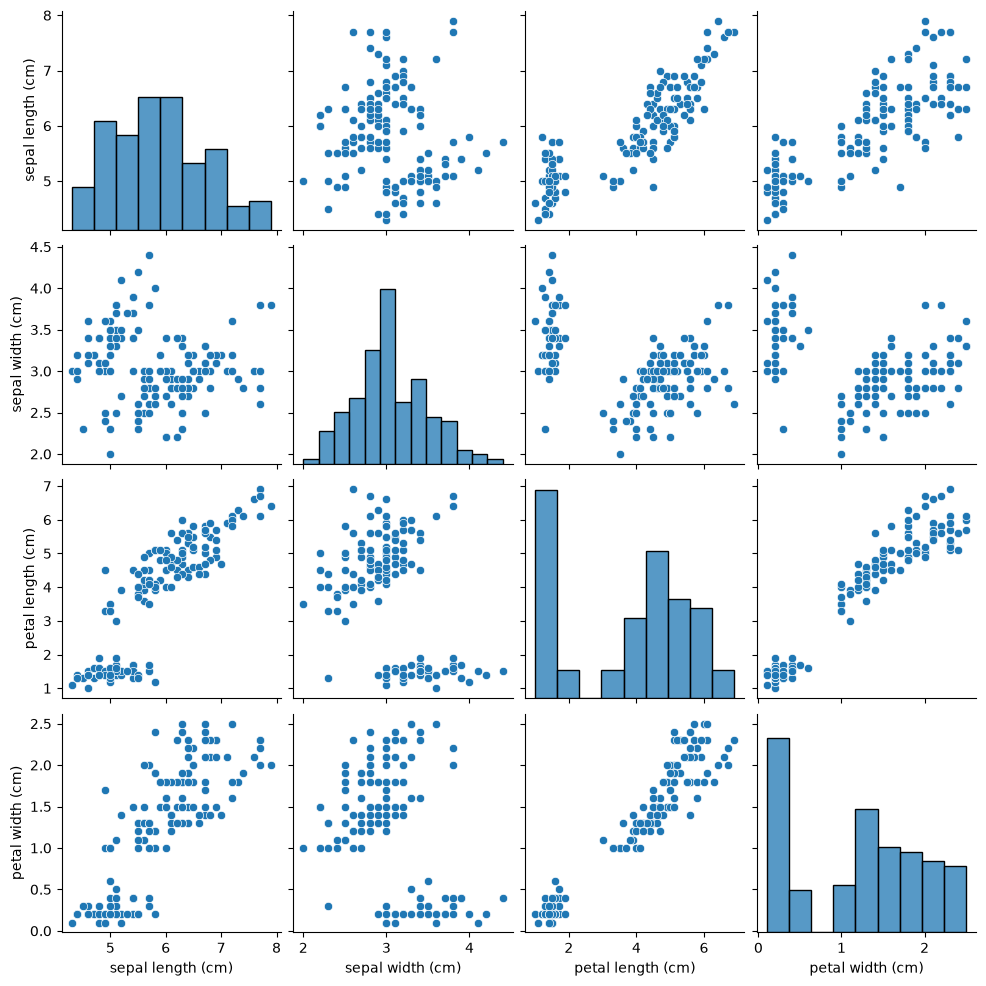

In [15]:

import seaborn as sns
from sklearn.datasets import load_iris

iris_data = load_iris(as_frame=True)

iris_df = iris_data["data"]
sns.pairplot(iris_df)

<Axes: >

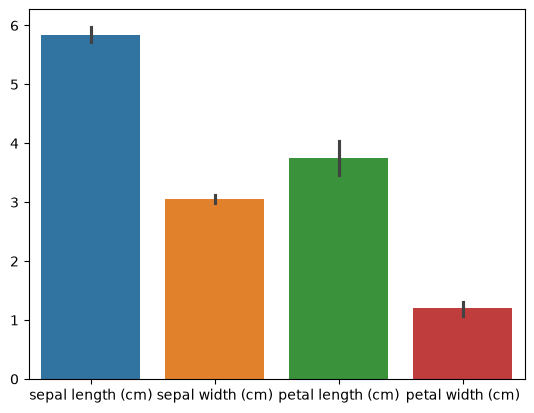

In [19]:
sns.barplot(iris_df)

<Axes: ylabel='count'>

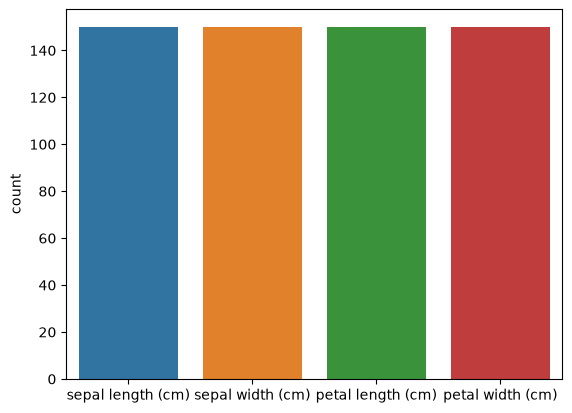

In [20]:
sns.countplot(iris_df)

<Axes: ylabel='Proportion'>

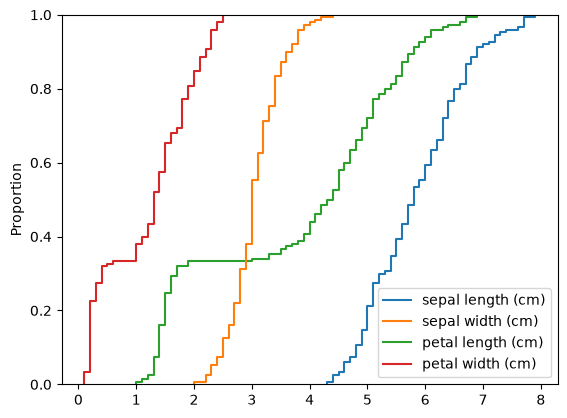

In [21]:
sns.ecdfplot(iris_df)

<Axes: >

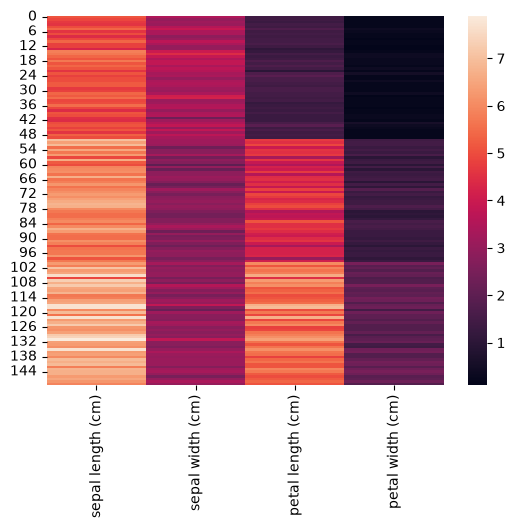

In [22]:
sns.heatmap(iris_df)

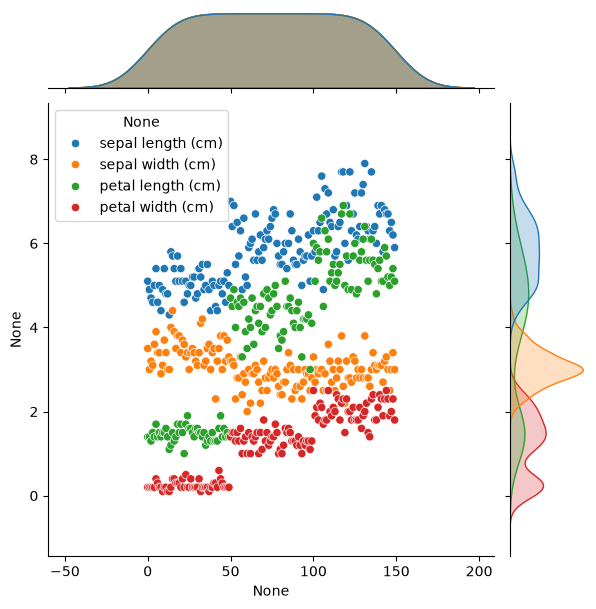

In [23]:
sns.jointplot(iris_df)

<Axes: >

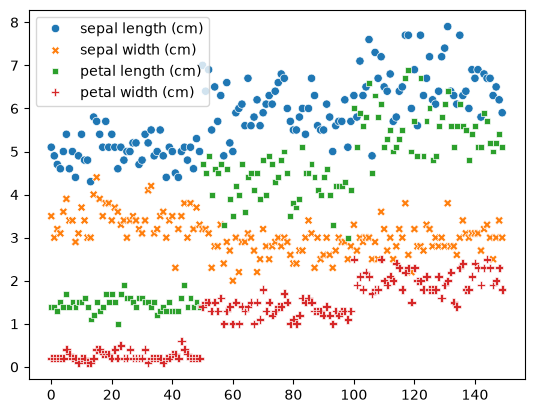

In [24]:
sns.scatterplot(iris_df)